In [1049]:
import subprocess
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import scipy.optimize as so
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from math import sqrt
import subprocess
from scipy.optimize import curve_fit
sns.set()
sns.set_context('paper', font_scale=1.2)
from scipy.optimize import nnls#######################################################################################################################################################################################################
#######################################################################################################################################################################################################
# Path: Newsimulation.ipynb
#######################################################################################################################################################################################################
#######################################################################################################################################################################################################

# Parse EnergyPlus datetime string
energyplus_install_dir=r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\EnergyPlusV9-6-0"
#energyplus_install_dir=r"D:\EnergyPlusV25-1-0"
output_relative_directory =  r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\DOF_change"
idf_relative_filepath = r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\SmallOffice.idf"
epw_relative_filepath = r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\USA_WA_Bellingham.Intl.AP.727976_US.Normals.1981-2010.epw"
#epw_relative_filepath = r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\USA_CO_Golden-NREL.724666_TMY3.epw"

#USA_CO_Denver.Intl.AP.725650_US.Normals.1991-2020.epw

#mychange - idf_relative_filepath = r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\AirflowNetwork_MultiZone_SmallOffice_VAV111.idf"
#USA_CA_San.Francisco.Intl.AP.724940_TMY3
#USA_CO_Golden-NREL.724666_TMY3
def run_command(cmd_string, capture_output=False):
    # sourcery skip: raise-specific-error
    result = subprocess.run(cmd_string, capture_output=capture_output)
    if result.returncode != 0:
        raise Exception(f'Command failed with return code: {result.returncode}')
    print('---RETURNCODE---\n', result.returncode, '(SUCCESS)')
    return result



# building command string
cl_st=(f'"{energyplus_install_dir}\\energyplus" '
       + '--readvars '
       + f'--output-directory "{output_relative_directory}" '
       + f'--weather "{epw_relative_filepath}" '
       + f'"{idf_relative_filepath}"'
      )


# running the simulation
run_command(cl_st)

---RETURNCODE---
 0 (SUCCESS)


CompletedProcess(args='"D:\\PhD_Academics\\Buildings\\Tharaka\\Tharaka\\EnergyPlusV9-6-0\\energyplus" --readvars --output-directory "D:\\PhD_Academics\\Buildings\\Tharaka\\Tharaka\\meeting\\james\\week4_solar_and_new_cost_function\\DOF_change" --weather "D:\\PhD_Academics\\Buildings\\Tharaka\\Tharaka\\meeting\\james\\week4_solar_and_new_cost_function\\USA_WA_Bellingham.Intl.AP.727976_US.Normals.1981-2010.epw" "D:\\PhD_Academics\\Buildings\\Tharaka\\Tharaka\\meeting\\james\\week4_solar_and_new_cost_function\\SmallOffice.idf"', returncode=0)

In [1051]:
# function to parse EnergyPlus datetime string
def parse_energyplus_datetime_string(st, year=2021):
    st = st.strip()
    month, day = map(int, [st[:2], st[3:5]])
    hour = int(st[7:9]) if st[7:9] != '24' else 0
    minute = int(st[10:12])
    dt = pd.Timestamp(year, month, day, hour, minute)
    return dt if st[7:9] != '24' else dt + pd.Timedelta('1 day')

In [1053]:
df=pd.read_csv(r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\DOF_change\eplusout.csv",
               parse_dates=[0],
               index_col=[0],
               date_parser=parse_energyplus_datetime_string
              )

df_sim = pd.read_csv(r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\DOF_change\eplusout.csv")

C:\Users\USER\AppData\Local\Temp\ipykernel_17472\3946068532.py:1: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  df=pd.read_csv(r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\DOF_change\eplusout.csv",


In [1054]:
rename_dict = {
    "NORTH ZONE:Zone Air Temperature [C](TimeStep)": "North_Zone_Air_Temperature", 
    "WEST ZONE:Zone Air Temperature [C](TimeStep)": "West_Zone_Air_Temperature", 
    "EAST ZONE:Zone Air Temperature [C](TimeStep)": "East_Zone_Air_Temperature", 
    "Environment:Site Outdoor Air Drybulb Temperature [C](TimeStep)": "Ambient_Temperature", 
    "MAIN HEATING COIL 1:Heating Coil Heating Rate [W](TimeStep)": "Heating_Power", 
    "ZONE3TERMREHEAT:Zone Air Terminal Sensible Heating Rate [W](TimeStep)": "Heating_Power_Z1",
    "ZONE1TERMREHEAT:Zone Air Terminal Sensible Heating Rate [W](TimeStep)": "Heating_Power_Z2",
    "ZONE2TERMREHEAT:Zone Air Terminal Sensible Heating Rate [W](TimeStep)": "Heating_Power_Z3",
    "NORTH ZONE:Zone Windows Total Transmitted Solar Radiation Rate [W](TimeStep)": "North_Zone_Solar_Rate",
    "NORTH ZONE:Zone Windows Total Transmitted Solar Radiation Energy [J](TimeStep)": "North_Zone_Solar_Energy",
    "WEST ZONE:Zone Windows Total Transmitted Solar Radiation Rate [W](TimeStep)": "West_Zone_Solar_Rate",
    "WEST ZONE:Zone Windows Total Transmitted Solar Radiation Energy [J](TimeStep)": "West_Zone_Solar_Energy",
    "EAST ZONE:Zone Windows Total Transmitted Solar Radiation Rate [W](TimeStep)": "East_Zone_Solar_Rate",
    "EAST ZONE:Zone Windows Total Transmitted Solar Radiation Energy [J](TimeStep)": "East_Zone_Solar_Energy",
    "Date/Time": "Time"
}
df.rename(columns=rename_dict, inplace=True)
time_steps = np.arange(len(df))
df['time_steps'] = time_steps

In [1055]:
rename_dict = {
    "NORTH ZONE:Zone Air Temperature [C](TimeStep)": "North_Zone_Air_Temperature", 
    "WEST ZONE:Zone Air Temperature [C](TimeStep)": "West_Zone_Air_Temperature", 
    "EAST ZONE:Zone Air Temperature [C](TimeStep)": "East_Zone_Air_Temperature", 
    "Environment:Site Outdoor Air Drybulb Temperature [C](TimeStep)": "Ambient_Temperature", 
    "MAIN HEATING COIL 1:Heating Coil Heating Rate [W](TimeStep)": "Heating_Power", 
    "ZONE3TERMREHEAT:Zone Air Terminal Sensible Heating Rate [W](TimeStep)": "Heating_Power_Z1",
    "ZONE1TERMREHEAT:Zone Air Terminal Sensible Heating Rate [W](TimeStep)": "Heating_Power_Z2",
    "ZONE2TERMREHEAT:Zone Air Terminal Sensible Heating Rate [W](TimeStep)": "Heating_Power_Z3",
    "NORTH ZONE:Zone Windows Total Transmitted Solar Radiation Rate [W](TimeStep)": "North_Zone_Solar_Rate",
    "NORTH ZONE:Zone Windows Total Transmitted Solar Radiation Energy [J](TimeStep)": "North_Zone_Solar_Energy",
    "WEST ZONE:Zone Windows Total Transmitted Solar Radiation Rate [W](TimeStep)": "West_Zone_Solar_Rate",
    "WEST ZONE:Zone Windows Total Transmitted Solar Radiation Energy [J](TimeStep)": "West_Zone_Solar_Energy",
    "EAST ZONE:Zone Windows Total Transmitted Solar Radiation Rate [W](TimeStep)": "East_Zone_Solar_Rate",
    "EAST ZONE:Zone Windows Total Transmitted Solar Radiation Energy [J](TimeStep)": "East_Zone_Solar_Energy",
    "Date/Time": "Time"
}
df.rename(columns=rename_dict, inplace=True)
time_steps = np.arange(len(df))
df['time_steps'] = time_steps

In [1056]:
minutes_to_plot = 2592000  # Define the number of minutes to plot

# Ensure that we have enough data to plot 200 minutes
if len(df) > minutes_to_plot:
    plot_data = df.iloc[:minutes_to_plot]
else:
    plot_data = df  # Not enough data, use what we have

# create and modify Heating Input column
df['Heating Input'] = df['Heating_Power'].apply(lambda x: 1 if x > 0 else 0).astype(int)
df['Heating_Input_Z1'] = df['Heating_Power_Z1'].apply(lambda x: 1 if x > 0 else 0).astype(int)
df['Heating_Input_Z2'] = df['Heating_Power_Z2'].apply(lambda x: 1 if x > 0 else 0).astype(int)
df['Heating_Input_Z3'] = df['Heating_Power_Z3'].apply(lambda x: 1 if x > 0 else 0).astype(int)

# Format the current date and time
timestamp = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')


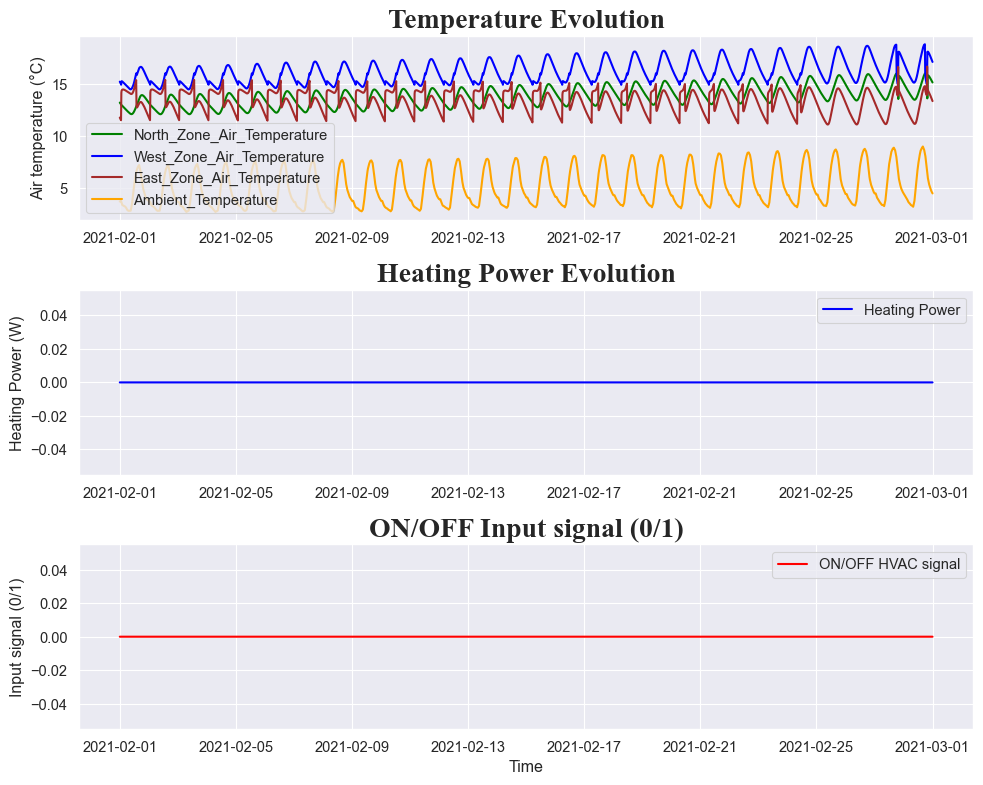

In [1057]:
# Specify the path and filename and save the DataFrame to a new CSV file
file_path =  r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\DOF_change"
filename = f"{file_path}imulation_results_{timestamp}.csv"
filename2 = r'D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\DOF_change\Indoor_Temperatures2.csv'
# Specify the file path

df.to_csv(filename, index=False)
df.to_csv(filename2, index=False)


fig, axs = plt.subplots(3, 1, figsize=(10, 8), tight_layout=True)
minutes_to_plot = 2592000   # Define the number of minutes to plot

# Ensure that we have enough data to plot 200 minutes
if len(df) > minutes_to_plot:
    plot_data = df.iloc[:minutes_to_plot]
else:
    plot_data = df  # Not enough data, use what we have

# Plot T_int1, T_int2, T_int3, T_ext
for temp, color in zip(['North_Zone_Air_Temperature', 'West_Zone_Air_Temperature', 'East_Zone_Air_Temperature', 'Ambient_Temperature'], ['green', 'blue', 'brown', 'orange']):
    axs[0].plot(plot_data.index, plot_data[temp], color=color, linewidth=1.5, label=temp)
axs[0].set(ylabel='Temperature (°C)')
axs[0].legend(loc='best')
axs[0].set_ylabel('Air temperature (°C)')
axs[0].set_title('Temperature Evolution', fontname="Times New Roman", size=20, fontweight="bold")

# Plot P_hea1
axs[1].plot(plot_data.index, plot_data['Heating_Power'], color='blue', linewidth=1.5, label='Heating Power')
axs[1].set(ylabel='Heating Power (W)')
axs[1].legend(loc='best')
axs[1].set_ylabel('Heating Power (W)')
axs[1].set_title('Heating Power Evolution', fontname="Times New Roman", size=20, fontweight="bold")

# Plot P_hea2
axs[2].plot(plot_data.index, plot_data['Heating Input'], color='red', linewidth=1.5, label='ON/OFF HVAC signal')
axs[2].set(xlabel='Time', ylabel='P_hea2')
axs[2].legend(loc='best')
axs[2].set_ylabel('Input signal (0/1)')
axs[2].set_title('ON/OFF Input signal (0/1)', fontname="Times New Roman", size=20, fontweight="bold")



plt.show()

plt.show()




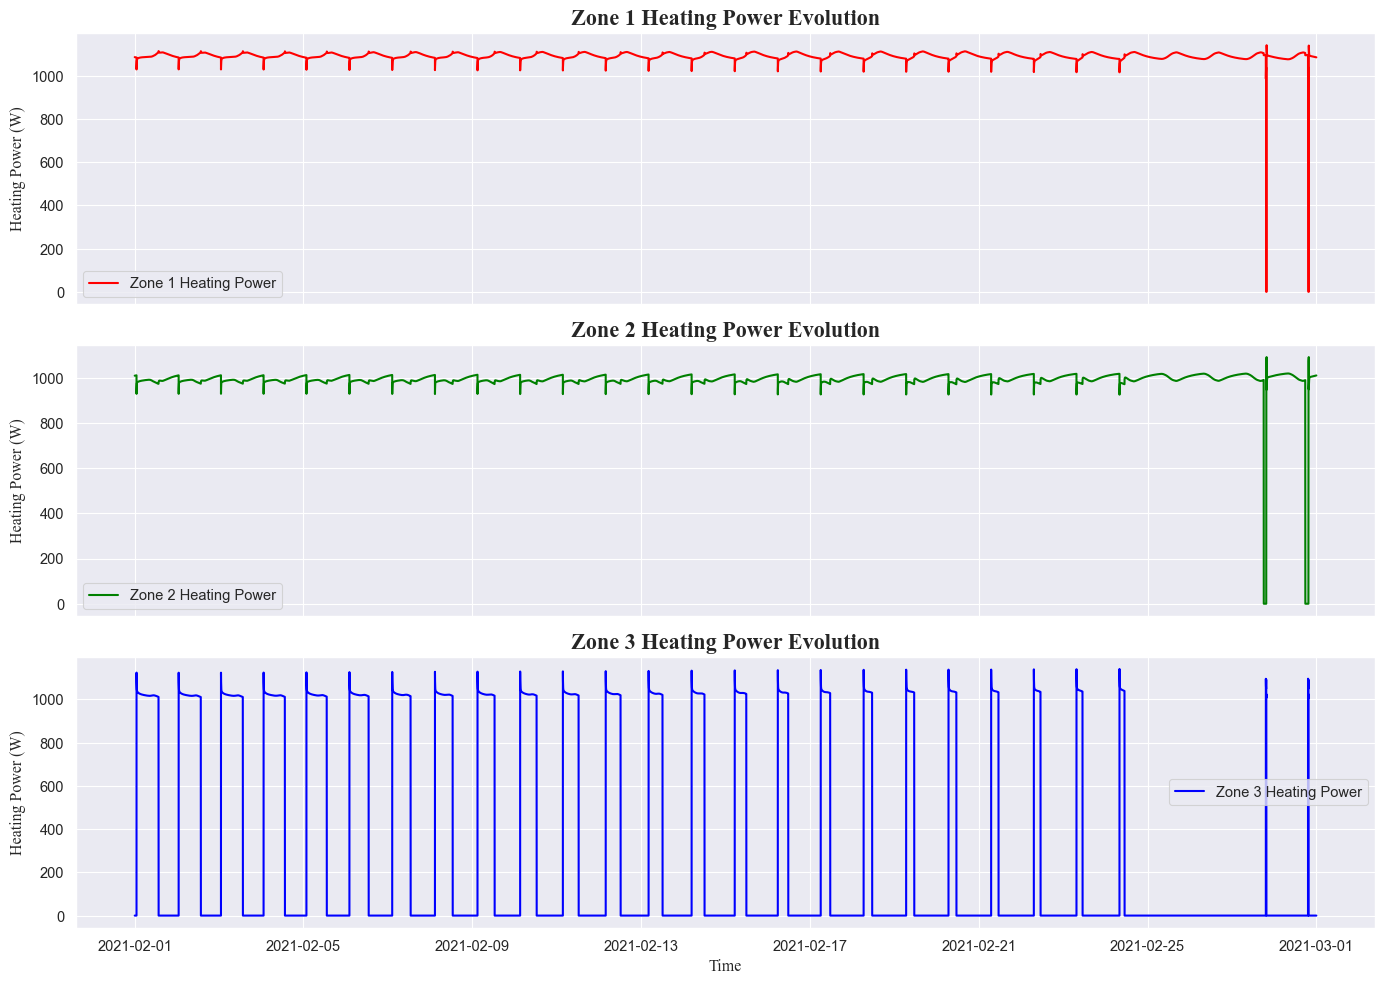

In [1058]:
fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
# Plot for Zone 1
axs[0].plot(df.index, df['Heating_Power_Z1'], color='red', linewidth=1.5, label='Zone 1 Heating Power')
axs[0].set_ylabel('Heating Power (W)', fontname="Times New Roman")
axs[0].legend(loc='best')
axs[0].set_title('Zone 1 Heating Power Evolution', fontname="Times New Roman", size=16, fontweight="bold")

# Plot for Zone 2
axs[1].plot(df.index, df['Heating_Power_Z2'], color='green', linewidth=1.5, label='Zone 2 Heating Power')
axs[1].set_ylabel('Heating Power (W)', fontname="Times New Roman")
axs[1].legend(loc='best')
axs[1].set_title('Zone 2 Heating Power Evolution', fontname="Times New Roman", size=16, fontweight="bold")

# Plot for Zone 3
axs[2].plot(df.index, df['Heating_Power_Z3'], color='blue', linewidth=1.5, label='Zone 3 Heating Power')
axs[2].set_ylabel('Heating Power (W)', fontname="Times New Roman")
axs[2].set_xlabel('Time', fontname="Times New Roman")
axs[2].legend(loc='best')
axs[2].set_title('Zone 3 Heating Power Evolution', fontname="Times New Roman", size=16, fontweight="bold")

plt.tight_layout()
plt.show()

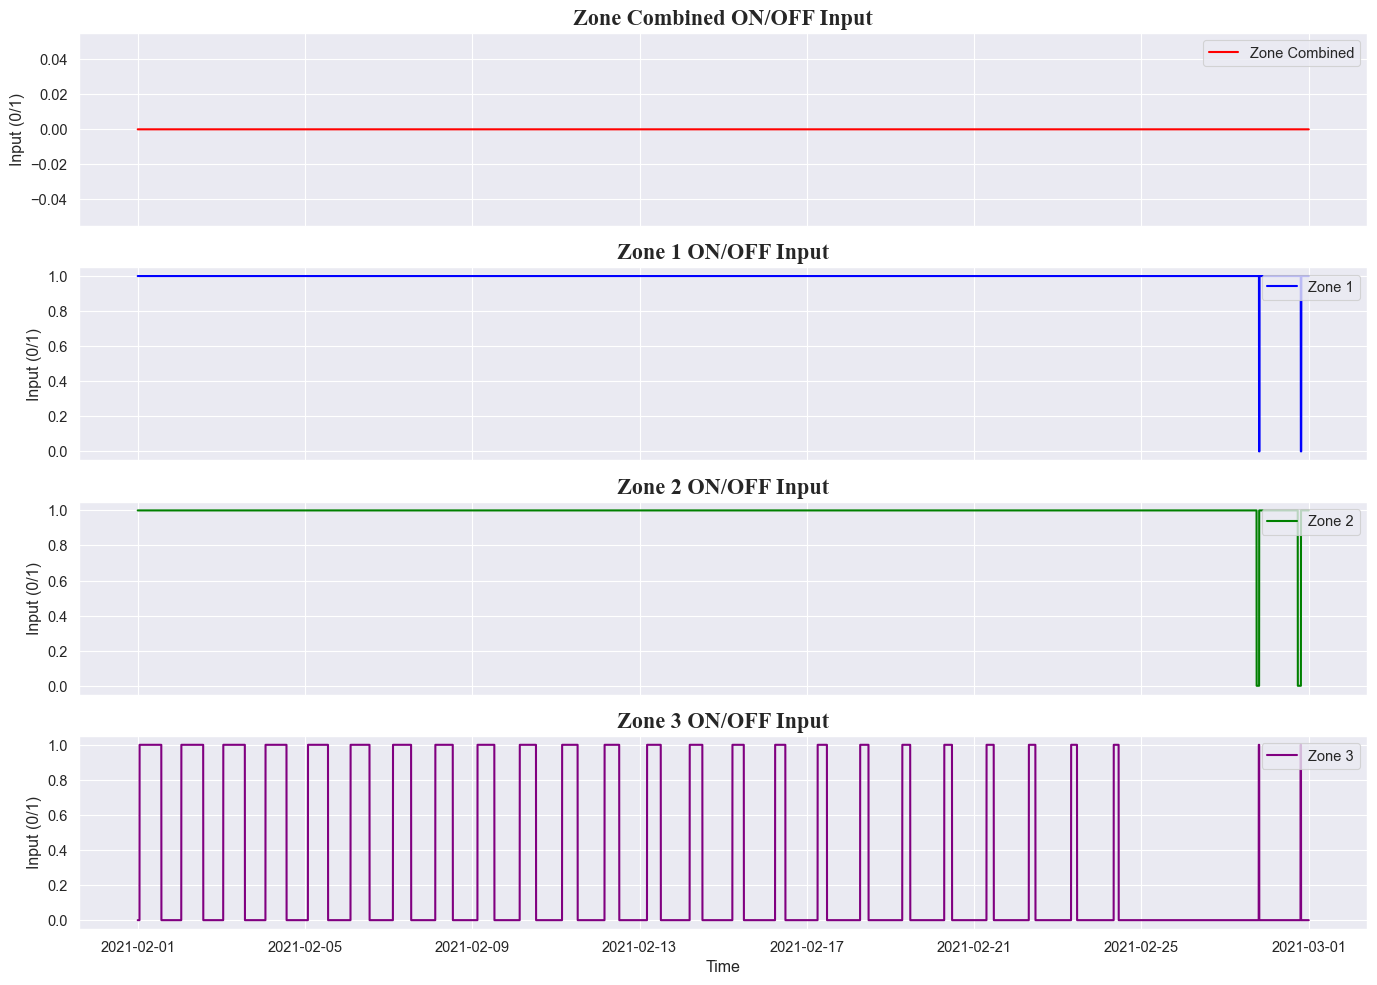

In [1059]:
import matplotlib.pyplot as plt

# Create subplots for Heating Input signals
fig, axs = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

# Plot for overall Heating Input
axs[0].plot(df.index, df['Heating Input'], color='red', linewidth=1.5, label='Zone Combined')
axs[0].set_ylabel('Input (0/1)')
axs[0].set_title('Zone Combined ON/OFF Input', fontname="Times New Roman", size=16, fontweight="bold")
axs[0].legend(loc='upper right')

# Plot for Zone 1
axs[1].plot(df.index, df['Heating_Input_Z1'], color='blue', linewidth=1.5, label='Zone 1')
axs[1].set_ylabel('Input (0/1)')
axs[1].set_title('Zone 1 ON/OFF Input', fontname="Times New Roman", size=16, fontweight="bold")
axs[1].legend(loc='upper right')

# Plot for Zone 2
axs[2].plot(df.index, df['Heating_Input_Z2'], color='green', linewidth=1.5, label='Zone 2')
axs[2].set_ylabel('Input (0/1)')
axs[2].set_title('Zone 2 ON/OFF Input', fontname="Times New Roman", size=16, fontweight="bold")
axs[2].legend(loc='upper right')

# Plot for Zone 3
axs[3].plot(df.index, df['Heating_Input_Z3'], color='purple', linewidth=1.5, label='Zone 3')
axs[3].set_ylabel('Input (0/1)')
axs[3].set_xlabel('Time')
axs[3].set_title('Zone 3 ON/OFF Input', fontname="Times New Roman", size=16, fontweight="bold")
axs[3].legend(loc='upper right')

plt.tight_layout()
plt.show()


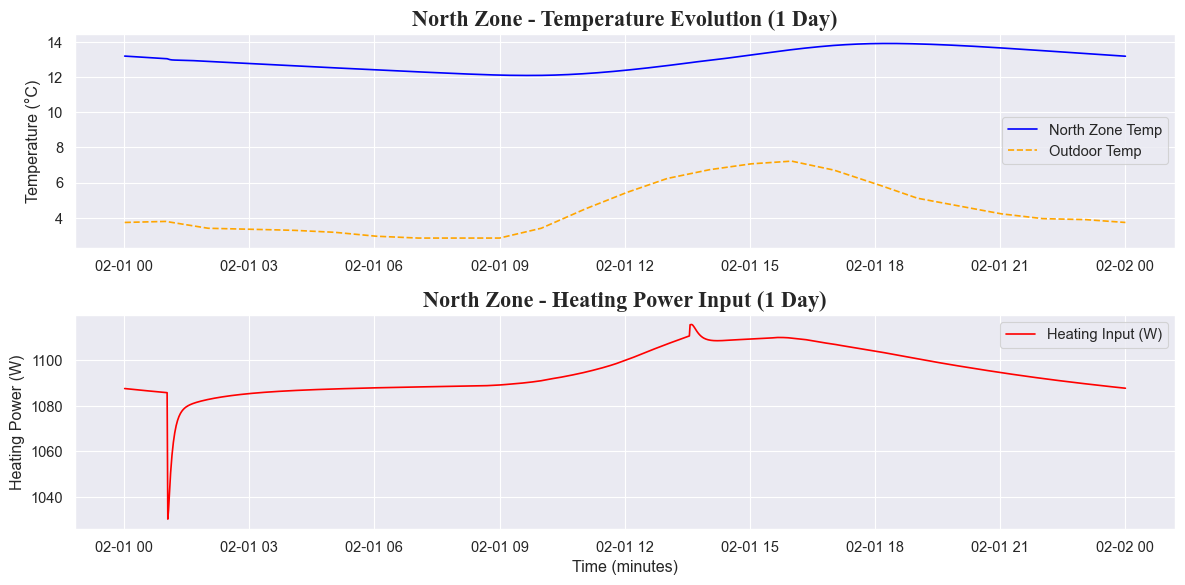

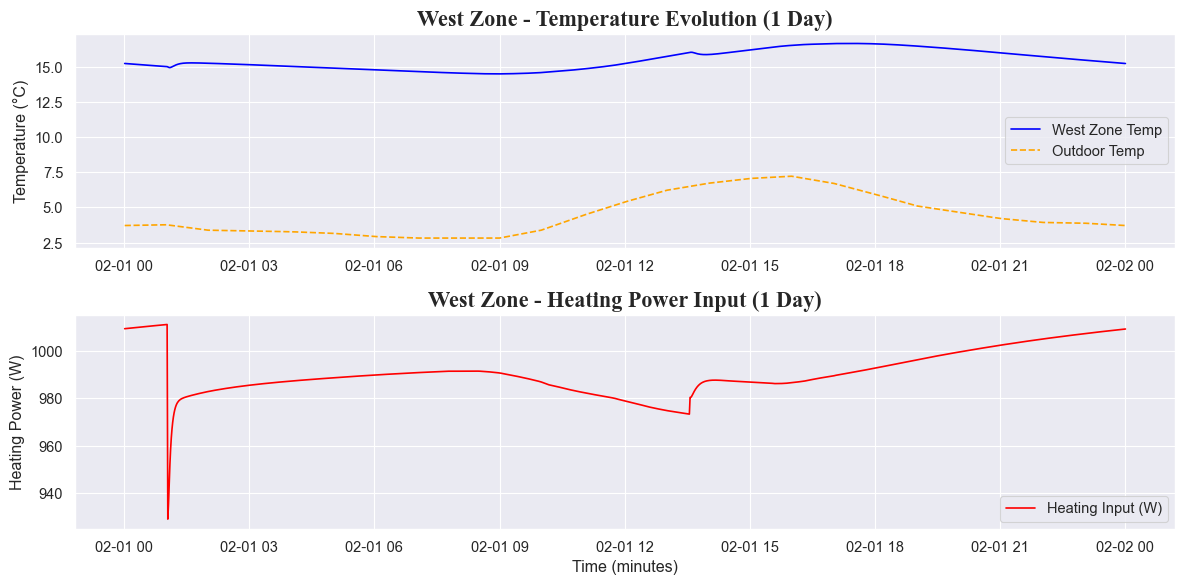

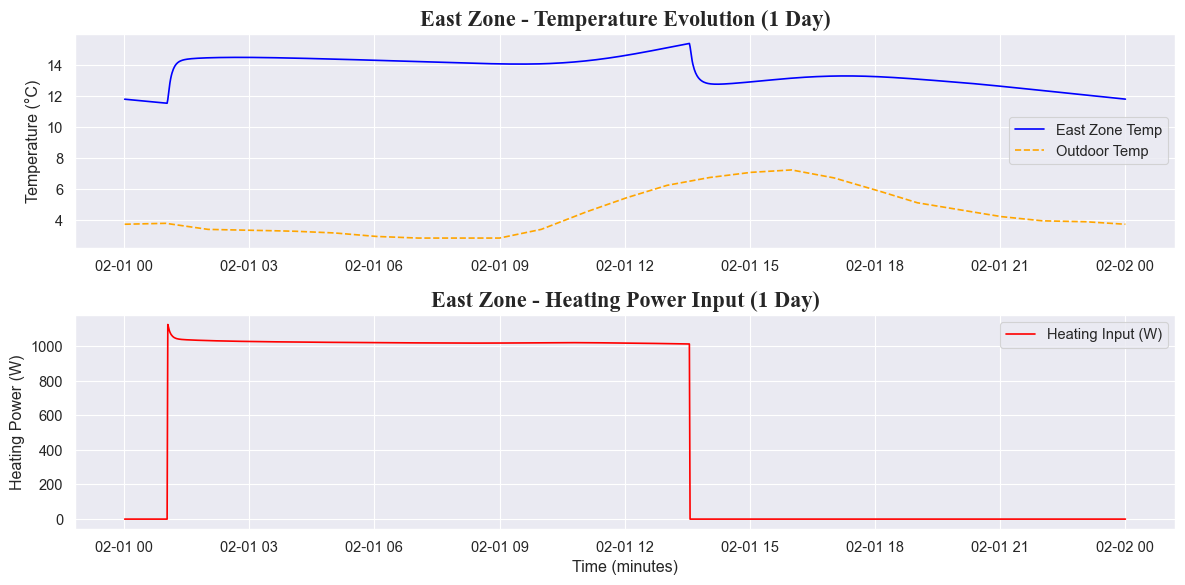

In [1060]:
import matplotlib.pyplot as plt

# Define how many minutes = 1 day
minutes_in_one_day = 1440  

# Ensure data is long enough
if len(df) >= minutes_in_one_day:
    day_data = df.iloc[:minutes_in_one_day]
else:
    day_data = df  # Use what we have

zones = [
    ('North_Zone_Air_Temperature', 'Heating_Power_Z1', 'North Zone'),
    ('West_Zone_Air_Temperature', 'Heating_Power_Z2', 'West Zone'),
    ('East_Zone_Air_Temperature', 'Heating_Power_Z3', 'East Zone'),
]

for temp_col, power_col, zone_name in zones:
    fig, axs = plt.subplots(2, 1, figsize=(12, 6), tight_layout=True)

    # Temperature subplot
    axs[0].plot(day_data.index, day_data[temp_col], label=f'{zone_name} Temp', color='blue')
    axs[0].plot(day_data.index, day_data['Ambient_Temperature'], label='Outdoor Temp', color='orange', linestyle='--')
    axs[0].set_ylabel('Temperature (°C)')
    axs[0].set_title(f'{zone_name} - Temperature Evolution (1 Day)', fontname="Times New Roman", fontsize=16, fontweight='bold')
    axs[0].legend()

    # Heating power input subplot
    axs[1].plot(day_data.index, day_data[power_col], label='Heating Input (W)', color='red')
    axs[1].set_ylabel('Heating Power (W)')
    axs[1].set_xlabel('Time (minutes)')
    axs[1].set_title(f'{zone_name} - Heating Power Input (1 Day)', fontname="Times New Roman", fontsize=16, fontweight='bold')
    axs[1].legend()

    plt.show()


[1.00000000e+04 6.50025905e+03 2.91922027e+03 8.12338019e-17
 1.21707774e+02 1.42097802e+02 5.28357601e+01 8.46617042e+01
 5.73039185e-20 2.28702360e-21]
D1: 5.730391847498953e-20
D2: 2.287023597957934e-21
   K12    K23    K10   K20   K30       C1      C2      C3   D1   D2
0  0.0  142.1  121.7  52.8  84.7  10000.0  6500.3  2919.2  0.0  0.0
RMSE for Zone 1: 1.18
RMSE for Zone 2: 0.88
RMSE for Zone 3: 0.77


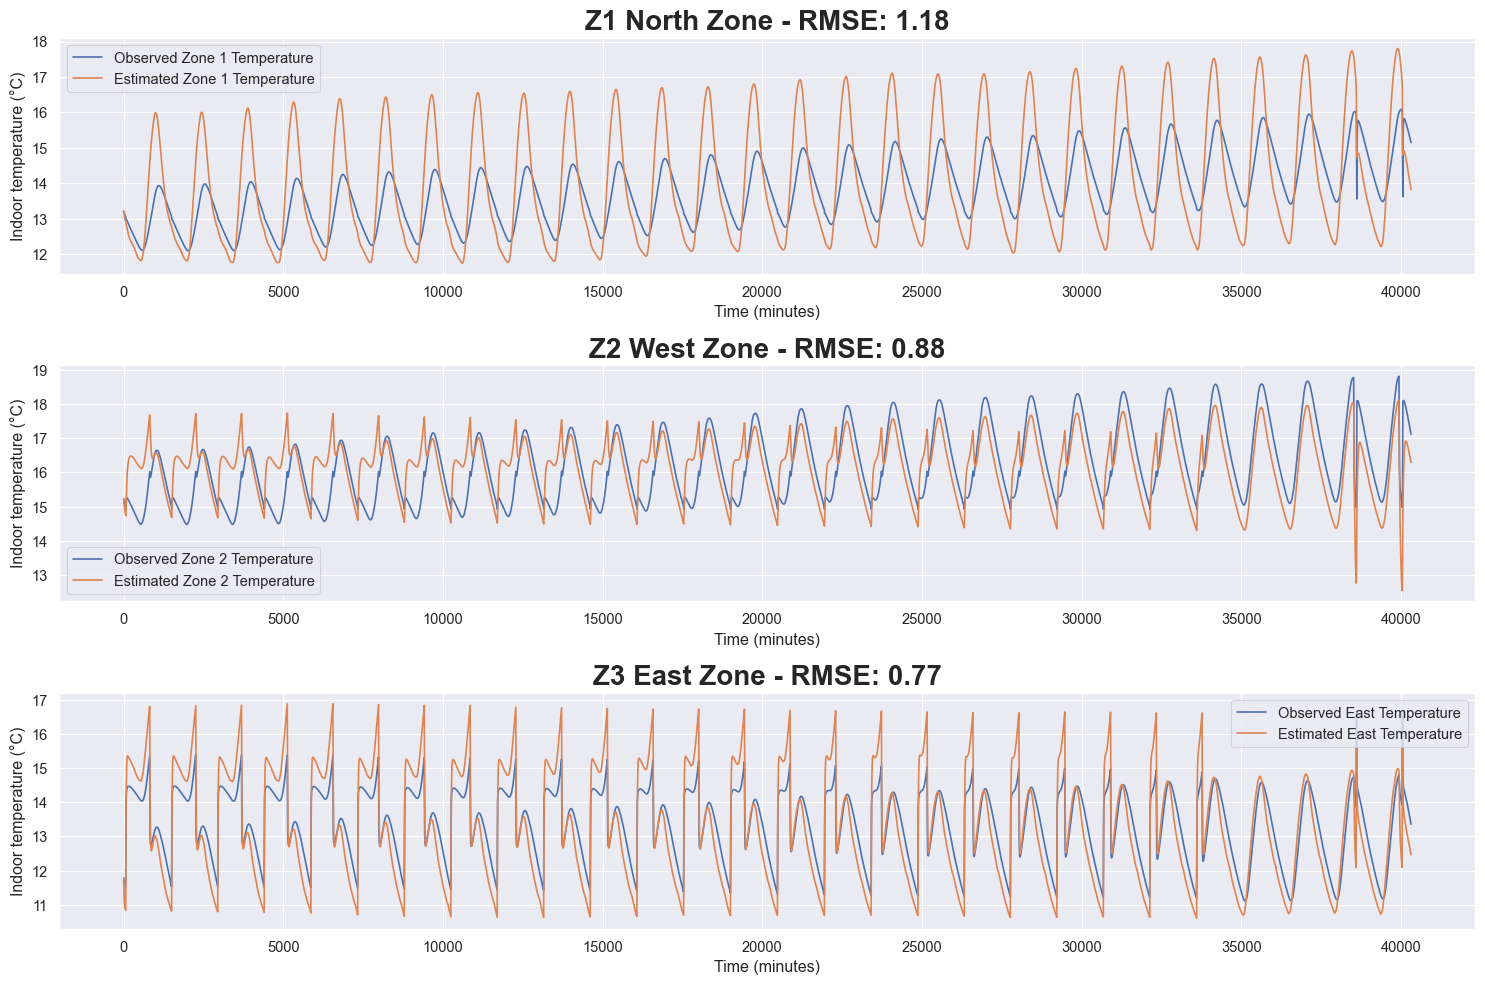

In [1061]:
############################################### NEW SOLAR BUT OLD MODEL AGAIN
from scipy.optimize import lsq_linear
#filename = r"C:\...\Resultssimulation_results_2024-06-08_02-07-16.csv"
df = pd.read_csv(filename)

time = df['time_steps'].values
num_steps = len(time)
dt = 1

# Extract data
T_outdoor = df['Ambient_Temperature'].values
zone1 = df['North_Zone_Air_Temperature'].values  
zone2 = df['West_Zone_Air_Temperature'].values 
zone3 = df['East_Zone_Air_Temperature'].values 
U1 = df['Heating_Power_Z1'].values
U2 = df['Heating_Power_Z2'].values
U3 = df['Heating_Power_Z3'].values
NS1 = df['North_Zone_Solar_Rate'].values
WS2 = df['West_Zone_Solar_Rate'].values
ES3 = df['East_Zone_Solar_Rate'].values
dt=1



# Compute temperature derivatives
dT1_dt = np.gradient(zone1, dt)
dT2_dt = np.gradient(zone2, dt)
dT3_dt = np.gradient(zone3, dt)

# Update number of parameters: C1, C2, C3, K12, K10, K23, K20, K30, D1, D2
num_params = 10
A = np.zeros((3 * num_steps, num_params))
b = np.zeros(3 * num_steps)
'''
# Fill matrices
for i in range(num_steps):
    A[3*i] = [
        dT1_dt[i], 0, 0,
        -(zone2[i] - zone1[i]),  # K12
        0,                       # K23 (skip)
        -(T_outdoor[i] - zone1[i]),  # K10
        0, 0,                    # K20, K30
        NS1[i], 0                # D1, D2
    ]
    
    A[3*i + 1] = [
        0, dT2_dt[i], 0,
        -(zone1[i] - zone2[i]),  # K12
        -(zone3[i] - zone2[i]),  # K23
        0,                       # K10
        -(T_outdoor[i] - zone2[i]),  # K20
        0,
        0, WS2[i]                # D1, D2
    ]
    
    A[3*i + 2] = [
        0, 0, dT3_dt[i],
        0,
        -(zone2[i] - zone3[i]),  # K23
        0, 0,
        -(T_outdoor[i] - zone3[i]),  # K30
        0, 0
    ]

    # ✅ Add this
    b[3*i]     = U1[i]
    b[3*i + 1] = U2[i]
    b[3*i + 2] = U3[i]



lower_bounds = np.zeros(10)
lower_bounds[8] = 0.1  # D1
lower_bounds[9] = 0.1 # D2
upper_bounds = np.full(10, np.inf)  # No upper bound

# Solve
from scipy.optimize import nnls
res = lsq_linear(A, b, bounds=(lower_bounds, upper_bounds), method='trf')
theta = res.x
#theta, rnorm = nnls(A, b)
C1, C2, C3, K12, K23, K10, K20, K30, D1, D2 = theta
'''

for i in range(num_steps):
    # Zone 1
    A[3*i] = [
        dT1_dt[i], 0, 0,
        -(zone2[i] - zone1[i]),   # K12
        -(T_outdoor[i] - zone1[i]),  # K10
        0, 0, 0,
        -NS1[i], 0  # D1
    ]
    b[3*i] = U1[i]

    # Zone 2
    A[3*i + 1] = [
        0, dT2_dt[i], 0,
        -(zone1[i] - zone2[i]),   # K12
        0,
        -(zone3[i] - zone2[i]),   # K23
        -(T_outdoor[i] - zone2[i]),  # K20
        0,
        0, -WS2[i]  # D2
    ]
    b[3*i + 1] = U2[i]

    # Zone 3
    A[3*i + 2] = [
        0, 0, dT3_dt[i],
        0,
        0,
        -(zone2[i] - zone3[i]),  # K23
        0,
        -(T_outdoor[i] - zone3[i]),  # K30
        0, 0
    ]
    b[3*i + 2] = U3[i]

# Solve NNLS
# Order:       [C1,    C2,    C3,    K12,   K10,   K23,   K20,   K30,   D1,   D2]
lower_bounds = [0,   0,   0,   0,   0,   0,   0,   0,   0.0,  0.0]  # example: D1/D2 ≥ 0.5
#upper_bounds = [np.inf]*10  # or specify [10000, ..., 2.0, 2.0] if you want to cap D1/D2 at 2.0
upper_bounds = [
    10000.0,  # C1
    10000.0,  # C2
    10000.0,  # C3
    1000.0,   # K12
    1000.0,   # K10
    1000.0,   # K23
    1000.0,   # K20
    1000.0,   # K30
    5.0,      # D1
    5.0       # D2
]

res = lsq_linear(A, b, bounds=(lower_bounds, upper_bounds), method='trf')
theta = res.x




#theta, rnorm = nnls(A, b)
C1, C2, C3, K12, K10, K23, K20, K30, D1, D2 = theta
theta
print(theta)

# Print the identified parameters

print(f"D1: {D1}")
print(f"D2: {D2}")
#print(f"D3: {D3}")


# Round each value to one decimal place
data_dict = {
    'K12': round(K12, 1), 
    'K23': round(K23, 1), 
    'K10': round(K10, 1), 
    'K20': round(K20, 1), 
    'K30': round(K30, 1), 
    'C1': round(C1, 1), 
    'C2': round(C2, 1), 
    'C3': round(C3, 1),
    'D1': round(D1, 1),
    'D2': round(D2, 1),
 #   'D3': round(D3, 1)
}

# Convert the dictionary to a DataFrame
df = pd.DataFrame([data_dict])
print(df)
# Specify the file path
#Rc_Parameters = r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week3_parameter_freezing\DOF_change\Parameter_Estimates.csv"

# Check if file exists and is not empty
#if os.path.isfile(Rc_Parameters) and os.path.getsize(Rc_Parameters) > 0:
    # If file exists and is not empty, do not write header
 #   df.to_csv(Rc_Parameters, mode='a', header=False, index=False)
#else:
    # If file doesn't exist or is empty, write header
#    df.to_csv(Rc_Parameters, mode='w', header=True, index=False)
    
#K12=K12+1000  
###############################################################################################################################    
D3=0 #just for measuring
######################################################################################################################    
# Calculate the estimated temperatures
estimated_zone1 = np.zeros(num_steps)
estimated_zone2 = np.zeros(num_steps)
estimated_zone3 = np.zeros(num_steps)

estimated_zone1[0] = zone1[0]  # Initial temperature for zone1
estimated_zone2[0] = zone2[0]  # Initial temperature for zone2
estimated_zone3[0] = zone3[0]  # Initial temperature for zone3

for i in range(1, num_steps):
    estimated_zone1[i] = estimated_zone1[i-1] + (K12*(zone2[i-1] - estimated_zone1[i-1]) + K10*(T_outdoor[i-1] - estimated_zone1[i-1]) + U1[i-1] + D1*NS1[i-1] )/C1 * dt 
    estimated_zone2[i] = estimated_zone2[i-1] + (K12*(zone1[i-1] - estimated_zone2[i-1]) + K23*(zone3[i-1] - estimated_zone2[i-1]) + K20*(T_outdoor[i-1] - estimated_zone2[i-1]) + U2[i-1] + D2*WS2[i-1] )/C2 * dt 
    estimated_zone3[i] = estimated_zone3[i-1] + (K23*(zone2[i-1] - estimated_zone3[i-1]) + K30*(T_outdoor[i-1] - estimated_zone3[i-1]) + U3[i-1]  + D3 * ES3[i-1])/C3 * dt 
    
    
rmse_y1 = np.sqrt(mean_squared_error(zone1, estimated_zone1))
rmse_y2 = np.sqrt(mean_squared_error(zone2, estimated_zone2))
rmse_y3 = np.sqrt(mean_squared_error(zone3, estimated_zone3))


print(f"RMSE for Zone 1: {rmse_y1:.2f}")
print(f"RMSE for Zone 2: {rmse_y2:.2f}")
print(f"RMSE for Zone 3: {rmse_y3:.2f}")


# Round each value to one decimal place
RMSE = {
    'RMSE Zone 1': rmse_y1, 
    'RMSE Zone 2': rmse_y2, 
    'RMSE Zone 3': rmse_y3
}

df = pd.DataFrame([RMSE])

# Specify the file path
#RMSE = r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week3_parameter_freezing\DOF_change\RMSE.csv"





###########################################################################################################################################################################################################################
# Assuming `time` is an array or series that increments per minute, we trim all arrays to some number of minutes
minutes_to_plot = 2592000
if len(time) > minutes_to_plot:
    plot_time = time[:minutes_to_plot]
    plot_zone1 = zone1[:minutes_to_plot]
    plot_estimated_zone1 = estimated_zone1[:minutes_to_plot]
    plot_zone2 = zone2[:minutes_to_plot]
    plot_estimated_zone2 = estimated_zone2[:minutes_to_plot]
    plot_zone3 = zone3[:minutes_to_plot]
    plot_estimated_zone3 = estimated_zone3[:minutes_to_plot]
else:
    # Not enough data, use what we have
    plot_time = time
    plot_zone1 = zone1
    plot_estimated_zone1 = estimated_zone1
    plot_zone2 = zone2
    plot_estimated_zone2 = estimated_zone2
    plot_zone3 = zone3
    plot_estimated_zone3 = estimated_zone3
    
    
    
###########################################################################################################################################################################################################################    

# Create a DataFrame and save the verification data to a CSV file
data = {
    'Time': plot_time,
    'Observed_Temperature_Zone_1': plot_zone1,
    'Estimated_Temperature_Zone_1': plot_estimated_zone1,
    'Observed_Temperature_Zone_2': plot_zone2,
    'Estimated_Temperature_Zone_2': plot_estimated_zone2,
    'Observed_Temperature_Zone_3': plot_zone3,
    'Estimated_Temperature_Zone_3': plot_estimated_zone3,
    'Outdoor_Tmperature': T_outdoor
}
#df = pd.DataFrame(data)
# Save to CSV
#print(f"Verification Data Total Points: {len(plot_time)}")
#print(f"First time value: {plot_time[0]}, Last time value: {plot_time[-1]}")

#df.to_csv('D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting/james/week3_parameter_freezing/DOF_change/verification.csv', index=False)



##########################################################################################################################################################################################################################

#Plotting the results
plt.figure(figsize=(15, 10))
#plot_time=df
# North Zone
plt.subplot(3, 1, 1)
plt.plot(plot_time, plot_zone1, label='Observed Zone 1 Temperature')
plt.plot(plot_time, plot_estimated_zone1, label='Estimated Zone 1 Temperature')
#plt.plot(plot_time, T_outdoor , label='Outdoor Temperature')
plt.legend()
plt.title(f"Z1 North Zone - RMSE: {rmse_y1:.2f}", fontname="Arial", size=20, fontweight="bold")
plt.xlabel('Time (minutes)')
plt.ylabel('Indoor temperature (°C)')

# West Zone
plt.subplot(3, 1, 2)
plt.plot(plot_time, plot_zone2, label='Observed Zone 2 Temperature')
plt.plot(plot_time, plot_estimated_zone2, label='Estimated Zone 2 Temperature')
#plt.plot(plot_time, T_outdoor , label='Outdoor Temperature')
plt.legend()
plt.title(f"Z2 West Zone - RMSE: {rmse_y2:.2f}", fontname="Arial", size=20, fontweight="bold")
plt.xlabel('Time (minutes)')
plt.ylabel('Indoor temperature (°C)')

# East Zone
plt.subplot(3, 1, 3)
plt.plot(plot_time, plot_zone3, label='Observed East Temperature')
plt.plot(plot_time, plot_estimated_zone3, label='Estimated East Temperature')
#plt.plot(plot_time, T_outdoor , label='Outdoor Temperature')
plt.legend()
plt.title(f"Z3 East Zone - RMSE: {rmse_y3:.2f}", fontname="Arial", size=20, fontweight="bold")
plt.xlabel('Time (minutes)')
plt.ylabel('Indoor temperature (°C)')

plt.tight_layout()
plt.show()
#print(f"Total data points available: {len(time)}")#
#print(f"First time value: {time[0]}, Last time value: {time[-1]}")
